**Data Loading and Initial Inspection**

In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)

df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**Dataset Understanding and Statistical Summary**

In [2]:
df.info()
df.describe()
df['SalePrice'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


**Missing Value Analysis and Data Quality Assessment**

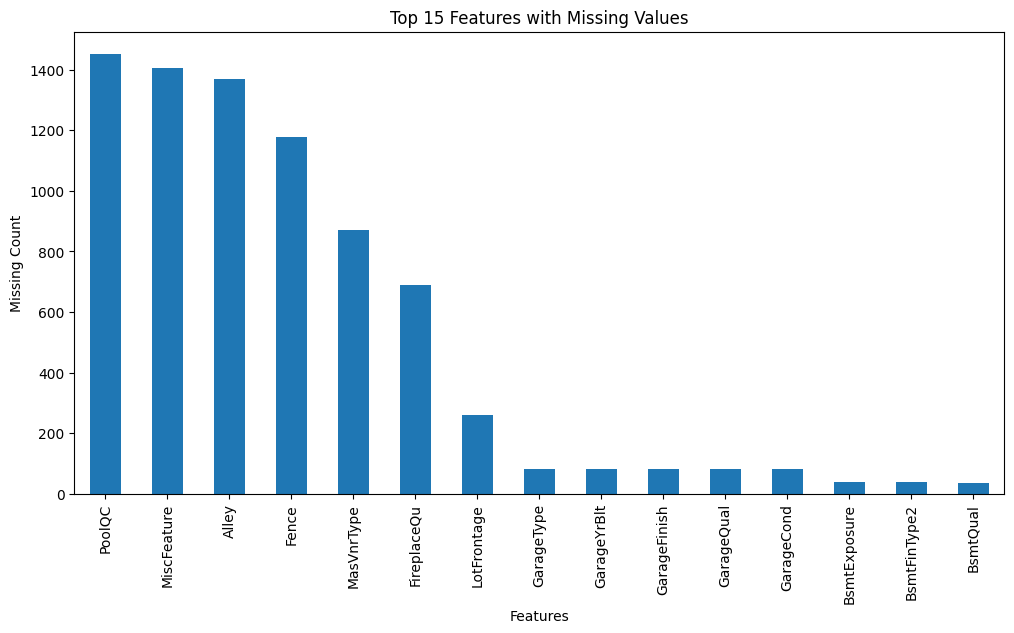

In [3]:
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_values.head(15).plot(kind='bar')

plt.title("Top 15 Features with Missing Values")
plt.xlabel("Features")
plt.ylabel("Missing Count")

plt.show()

**Exploratory Data Analysis (EDA) – Target Variable Analysis**

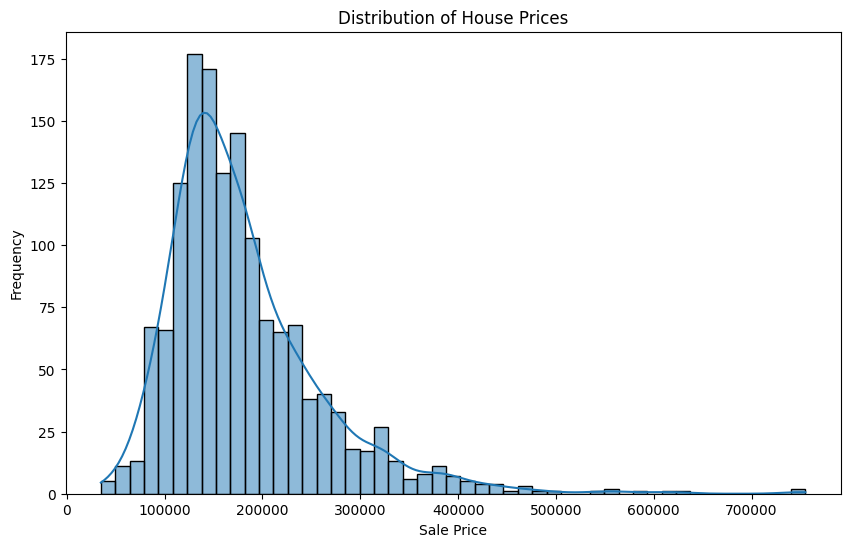

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(df['SalePrice'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

**Feature Relationship Analysis**


In [5]:
corr = df.corr(numeric_only=True)

saleprice_corr = corr['SalePrice'].sort_values(ascending=False)

print(saleprice_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


**Feature Selection and Modeling Dataset Creation**

In [16]:
features = [
    'GrLivArea',
    'BedroomAbvGr',
    'FullBath'
]

X = df[features]

y = df['SalePrice']

print(X.head())
print(y.head())

   GrLivArea  BedroomAbvGr  FullBath
0       1710             3         2
1       1262             3         2
2       1786             3         2
3       1717             3         1
4       2198             4         2
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


**Data Validation**

In [17]:
print(X.shape)

(1460, 3)


In [18]:
print(X.isnull().sum())

GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64


**Train-Test Split**

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1168, 3)
Testing Data Shape: (292, 3)


**Linear Regression Model Training**

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Number of Features:", len(model.coef_))

Intercept: 52261.74862694461
Number of Features: 3


**Model Evaluation and Performance Analysis**

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 35788.061292436294
MSE: 2806426667.247853
RMSE: 52975.71771338122
R2 Score: 0.6341189942328371


**Actual vs Predicted Price Visualization**

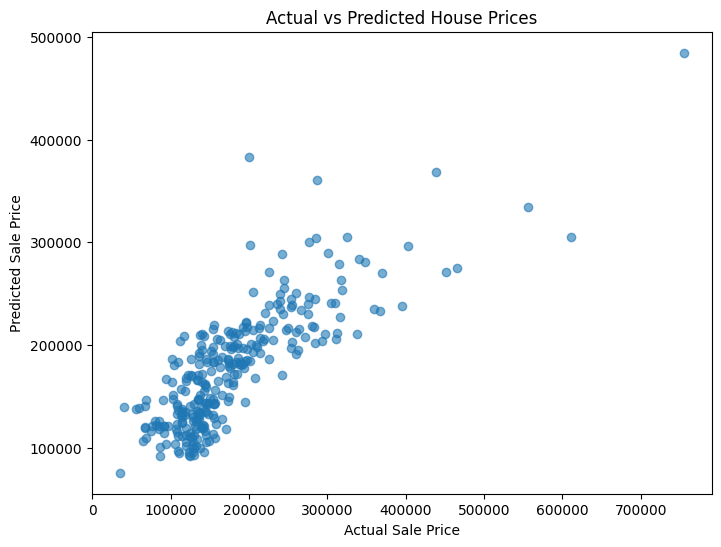

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

**User-Based House Price Prediction**

In [23]:
gr_liv_area = float(input("Enter Living Area (sq ft): "))
bedrooms = int(input("Enter Number of Bedrooms: "))
bathrooms = int(input("Enter Number of Bathrooms: "))

house = pd.DataFrame({
    'GrLivArea': [gr_liv_area],
    'BedroomAbvGr': [bedrooms],
    'FullBath': [bathrooms]
})

predicted_price = model.predict(house)

print(f"\nPredicted House Price: ${predicted_price[0]:,.2f}")

Enter Living Area (sq ft): 2500
Enter Number of Bedrooms: 5
Enter Number of Bathrooms: 5

Predicted House Price: $329,123.31
